# Predicting the race result before the start — Formula 1, 2026 season

**Question.** Starting position is the obvious forecast of a race result. What else is known before
the lights go out, and does it predict the finishing order or the chances of a podium or points
better than the grid alone?

**Approach.** For every race, a forecast built *only from earlier races* (rolling origin): the grid,
the qualifying gap to pole, recent team form, practice long-run pace and team reliability. A linear
model for the finishing order, plus a Monte Carlo simulation for the probabilities.

**TL;DR**
1. **The grid is hard to beat.** It already has a rank correlation of 0.80 with the result. Forecast
   only from earlier races, adding the qualifying gap and team form lifts that to **0.82** and cuts
   the mean error from 2.07 to 2.01 places. It is better in 5 of 13 races, level in 5 and worse
   in 3, which is not a reliable gain.
2. **Practice long-run pace** predicts the result on its own, but adds nothing once the grid,
   qualifying gap and team form are known.
3. **Reliability follows the team.** 20 % of starters do not finish in 2026, from 3 % at Racing
   Bulls to 53 % at Aston Martin. The rate is stable through the season (r = 0.87 between halves).
   From race 8 on, a team's record forecasts retirements 8 % better than a flat rate.
4. **Points chances are where the model pays off.** Its points-finish probabilities have **4.7 %
   lower log loss** than the grid's and are better in 9 of 13 races; the bootstrap interval
   excludes zero. The gains for podium and win are within noise. The probabilities are calibrated.
5. **Reliability does not sharpen the probabilities.** The least reliable teams are also the
   slowest, so their retirements rarely change who scores.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

import sys; sys.path.insert(0, '..')
from analysis.clean import clean_laps
from analysis import model as M, practice as F, predict as P

warnings.filterwarnings('ignore')
pd.set_option('display.precision', 3)
plt.rcParams.update({'figure.figsize': (9, 4.2), 'figure.dpi': 110, 'axes.grid': True,
                     'grid.alpha': .25, 'axes.spines.top': False, 'axes.spines.right': False})
N_SIM = 5000

res = pd.read_parquet(Path('../data/results_2026.parquet'))
print(f'{len(res)} driver entries in {res.race.nunique()} races')
res.status.value_counts().rename('entries').to_frame().T

352 driver entries in 16 races


status,finished,dnf,dns,nc
entries,276,67,7,2


## 1. Data
`data/results_2026.parquet` (built by `python -m analysis.dataset 2026 --session results`): the
official starting grid (with penalties and pit-lane starts), the best qualifying lap, the race
classification and status. *nc* = took the flag but completed under 90 % of the distance, so not
classified. Did-not-start entries are dropped below.

One number stands out for 2026: about **one car in five does not finish**.

In [2]:
res = res[res.status != 'dns'].copy()
out = res.status.isin(['dnf', 'nc'])
print(f'{out.mean():.0%} of starters did not finish or were not classified · '
      f'grid differs from qualifying for {(res.grid != res.quali_pos).sum()} entries (penalties, pit-lane starts)')

20% of starters did not finish or were not classified · grid differs from qualifying for 90 entries (penalties, pit-lane starts)


## 2. What is known before the start
* **grid**: official starting position;
* **qualifying gap**: best qualifying lap vs pole, %; it says *how much* faster, not only the order;
* **team form**: the team's average finishing position in the previous 3 races;
* **practice pace**: long runs from the [strategy study](strategy_sim.ipynb), section 6, adjusted to
  new MEDIUM tyres and compared with the median run of the same session, %.

In [3]:
laps = pd.read_parquet(Path('../data/laps_2026.parquet'))
fp = pd.read_parquet(Path('../data/laps_2026_practice.parquet'))
clean, _ = clean_laps(laps)
fuel = M.fuel_effect(M.fit_season(clean))[0]
runs = F.long_runs(fp, fuel)
pdeg = F.practice_deg(runs).set_index(['race', 'compound'])['deg']
rdeg = M.deg_by_race(clean, fuel)
season_deg = rdeg.groupby('compound').deg_s_per_lap.median()
deg = {(r, c): pdeg.get((r, c), season_deg[c]) for r in runs.race.unique() for c in season_deg.index}
params = {}
for race in laps.race.unique():
    try:
        params[race] = M.race_params(M.fit_race(clean[clean.race == race], fuel))
    except ValueError:
        pass
offsets = (pd.DataFrame([{'compound': c, 'gap': v - p['offset']['MEDIUM']} for p in params.values()
                         if 'MEDIUM' in p['offset'] for c, v in p['offset'].items()])
           .groupby('compound').gap.median())
pace = P.practice_pace(runs, deg, offsets)
d = P.add_form(res.merge(pace, on=['race', 'driver_number'], how='left'))
fin = d[d.status == 'finished']
print(f'practice pace available for {d.pace.notna().mean():.0%} of entries')
fin[['finish', 'grid', 'quali_gap', 'form_team', 'form_driver', 'pace']].corr(method='spearman')['finish'].drop('finish').rename('rank correlation with finish').to_frame()

practice pace available for 81% of entries


,rank correlation with finish
grid,0.802
quali_gap,0.829
form_team,0.777
form_driver,0.765
pace,0.667


All of them track the result. The question is what each adds **on top of the grid**. Fitted on all
classified finishers at once (standard errors clustered by race):

In [4]:
x = fin.dropna(subset=['quali_gap', 'form_team', 'pace']).reset_index(drop=True)
rows = []
for f in ['grid', 'grid + quali_gap', 'grid + form_team', 'grid + pace', 'grid + quali_gap + form_team + pace']:
    m = smf.ols('finish ~ ' + f, x).fit(cov_type='cluster', cov_kwds={'groups': pd.factorize(x['round'])[0]})
    rows.append({'model': f, 'R²': m.rsquared,
                 **{k: f'{v:+.2f} (p {m.pvalues[k]:.3f})' for k, v in m.params.items() if k != 'Intercept'}})
print(f'{len(x)} finishers with all features')
pd.DataFrame(rows).set_index('model').fillna('')

215 finishers with all features


,R²,grid,quali_gap,form_team,pace
model,,,,,
grid,0.631,+0.70 (p 0.000),,,
grid + quali_gap,0.678,+0.32 (p 0.001),+1.86 (p 0.000),,
grid + form_team,0.703,+0.40 (p 0.000),,+0.51 (p 0.000),
grid + pace,0.656,+0.56 (p 0.000),,,+0.95 (p 0.000)
grid + quali_gap + form_team + pace,0.718,+0.23 (p 0.001),+0.99 (p 0.008),+0.40 (p 0.000),+0.24 (p 0.295)


Fitted on the whole season, every feature adds to the grid. The qualifying gap (how far behind pole,
not only where) and team form are the strongest. Practice pace is significant on its own (about one
place per 1 % slower) but not once the others are in (p ≈ 0.3): what it measures is already in
qualifying and form. An in-sample fit flatters, though, so the next section tests the features on
races the model has not seen.

## 3. Forecasting the finishing order
Now the honest test: each race from the 4th on is forecast by a model fitted **only on earlier
races**. Scored among classified finishers: rank correlation with the result, mean error in
places, whether the winner was picked, and how many of the podium were.

In [5]:
FORMULAS = {'grid only': 'grid',
            'grid + quali gap': 'grid + quali_gap',
            'grid + team form': 'grid + form_team',
            'grid + quali gap + team form': 'grid + quali_gap + form_team',
            '+ practice pace': 'grid + quali_gap + form_team + pace'}
ranks = P.rolling_ranks(d, FORMULAS)
summary = ranks.groupby('model')[['rho', 'mae', 'winner', 'podium']].mean().reindex(FORMULAS)
summary.columns = ['rank correlation', 'mean error, places', 'winner picked', 'podium places picked (of 3)']
summary

,rank correlation,"mean error, places",winner picked,podium places picked (of 3)
model,,,,
grid only,0.803,2.069,0.615,1.769
grid + quali gap,0.810,2.055,0.615,1.769
grid + team form,0.818,2.056,0.462,1.769
grid + quali gap + team form,0.824,2.013,0.538,1.692
+ practice pace,0.821,2.006,0.615,1.846


In [6]:
w = ranks.pivot(index='round', columns='model', values='rho')
diff = w['grid + quali gap + team form'] - w['grid only']
print(f'{len(w)} races · grid + quali gap + team form vs grid only: better in {(diff > 0).sum()}, '
      f'equal in {(diff == 0).sum()}, worse in {(diff < 0).sum()} · mean difference {diff.mean():+.3f}')

13 races · grid + quali gap + team form vs grid only: better in 5, equal in 5, worse in 3 · mean difference +0.021


The grid is a hard baseline. The best combination raises rank correlation by 0.02 and cuts the mean
error by 0.06 places: better in 5 races, level in 5, worse in 3. It picks the winner slightly less
often (7 of 13 vs 8 of 13). The extra features reorder the midfield, where they help, while the front
of the grid is usually in order already. With 13 races, none of these differences is reliable.

## 4. Reliability
One car in five not finishing is a lot. Is it random, or does it follow the team?

In [7]:
rel = d.assign(out=d.status.isin(['dnf', 'nc'])).groupby('team').out.agg(['sum', 'size', 'mean'])
rel.columns = ['did not finish', 'starts', 'rate']
rounds = sorted(d['round'].unique())
half = d.assign(out=d.status.isin(['dnf', 'nc']),
                half=np.where(d['round'] <= rounds[len(rounds) // 2 - 1], 'first half', 'second half'))
halves = half.pivot_table(index='team', columns='half', values='out', aggfunc='mean')
print(f'team rate, first vs second half of the season: correlation {halves.corr().iloc[0, 1]:.2f}')
rel.join(halves).sort_values('rate')

team rate, first vs second half of the season: correlation 0.87


,did not finish,starts,rate,first half,second half
team,,,,,
Racing Bulls,1,31,0.032,0.067,0.000
Alpine,3,32,0.094,0.062,0.125
Audi,3,30,0.100,0.143,0.062
Ferrari,4,32,0.125,0.125,0.125
Mercedes,4,32,0.125,0.125,0.125
McLaren,4,29,0.138,0.154,0.125
Haas F1 Team,5,32,0.156,0.188,0.125
Red Bull Racing,6,32,0.188,0.250,0.125
Williams,9,31,0.290,0.267,0.312


In [8]:
ll = P.dnf_log_loss(d)
for start, part in (('4', ll), ('8', ll[ll['round'] >= rounds[7]])):
    print(f'from race {start}: log loss, same rate for all {part.season.mean():.3f} · '
          f'team rate {part.team.mean():.3f} ({1 - part.team.mean() / part.season.mean():.0%} better)')

from race 4: log loss, same rate for all 0.520 · team rate 0.498 (4% better)
from race 8: log loss, same rate for all 0.478 · team rate 0.439 (8% better)


Retirements are not random. The rate runs from 3 % at Racing Bulls to 53 % at Aston Martin, and a
team's rate in the first half of the season predicts the second (correlation 0.87). Using the
team's own record, shrunk towards the season average with the weight of 10 races, forecasts
retirements 4 % better from race 4 and 8 % better from race 8, once there is enough history.

## 5. Probabilities: win, podium, points
For each race, 5,000 simulations: every car retires with its probability, the rest finish in the
model's order plus normal noise with the spread of the model's errors on earlier races. Scored by
log loss on what happened (lower is better), against the same simulation driven by the grid alone.

In [9]:
CONFIGS = {'grid only': ('grid', 'season'),
           'grid + quali gap + team form': ('grid + quali_gap + form_team', 'season'),
           '+ team reliability': ('grid + quali_gap + form_team', 'team')}
prob = P.rolling_probabilities(d, CONFIGS, n=N_SIM)
score = prob.groupby(['model', 'event']).apply(lambda g: P.log_loss(g.p, g.y)).unstack().reindex(CONFIGS)
score[['win', 'podium', 'points']]

event,win,podium,points
model,,,
grid only,0.117,0.236,0.511
grid + quali gap + team form,0.115,0.228,0.487
+ team reliability,0.114,0.230,0.499


In [10]:
# Улучшение по гонкам и бутстреп по гонкам (гонки независимы, пилоты внутри — нет)
per_race = prob.groupby(['model', 'event', 'round']).apply(lambda g: P.log_loss(g.p, g.y)).unstack('model')
rng = np.random.default_rng(1)
rows = []
for ev in ('win', 'podium', 'points'):
    t = per_race.loc[ev]
    gain = 1 - t['grid + quali gap + team form'] / t['grid only']
    diff = t['grid only'] - t['grid + quali gap + team form']
    boot = [diff.sample(len(diff), replace=True, random_state=rng.integers(1e9)).mean() for _ in range(4000)]
    rows.append({'event': ev, 'better in races': f'{(diff > 0).sum()} of {len(diff)}',
                 'log loss reduction': 1 - t['grid + quali gap + team form'].mean() / t['grid only'].mean(),
                 '95% CI of the reduction (abs.)': f'{np.percentile(boot, 2.5):+.4f} … {np.percentile(boot, 97.5):+.4f}'})
pd.DataFrame(rows).set_index('event')

,better in races,log loss reduction,95% CI of the reduction (abs.)
event,,,
win,7 of 13,0.023,-0.0067 … +0.0147
podium,6 of 13,0.032,-0.0126 … +0.0382
points,9 of 13,0.047,+0.0059 … +0.0457


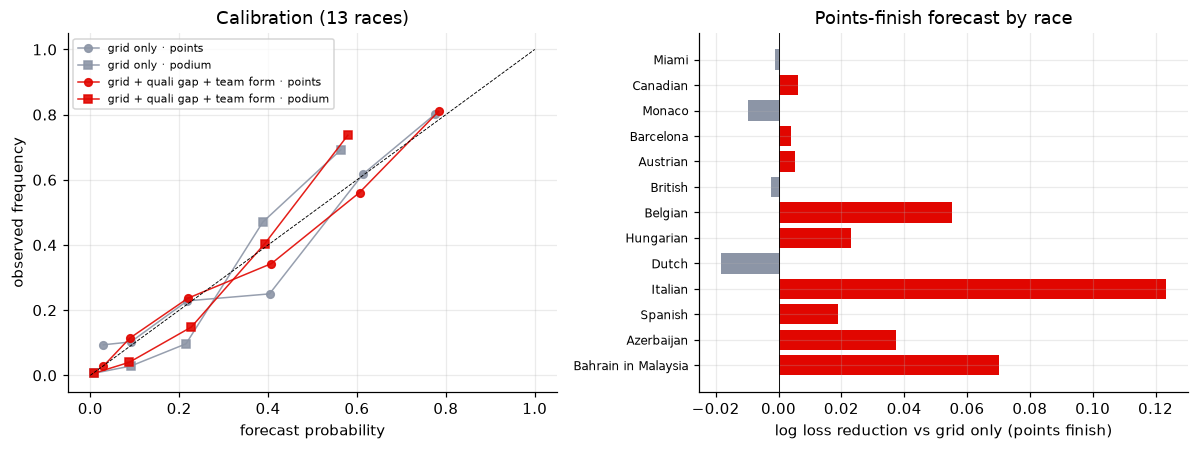

In [11]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
bins = np.array([0, .05, .15, .3, .5, .7, .85, .95, 1.0001])
for name, col in (('grid only', '#8c95a6'), ('grid + quali gap + team form', '#e10600')):
    for ev, mk in (('points', 'o'), ('podium', 's')):
        g = prob[(prob.model == name) & (prob.event == ev)]
        b = pd.cut(g.p, bins, include_lowest=True)
        c = g.groupby(b, observed=True).agg(p=('p', 'mean'), y=('y', 'mean'), n=('y', 'size'))
        a1.plot(c.p, c.y, marker=mk, color=col, lw=1, ms=5, alpha=.9,
                label=f'{name} · {ev}')
a1.plot([0, 1], [0, 1], color='k', lw=.6, ls='--')
a1.set(xlabel='forecast probability', ylabel='observed frequency', title='Calibration (13 races)')
a1.legend(fontsize=7)
t = per_race.loc['points']
order = ranks.drop_duplicates('round').set_index('round')['race'].str.replace(' Grand Prix', '')
y = np.arange(len(t))
a2.barh(y, (t['grid only'] - t['grid + quali gap + team form']).to_numpy(),
        color=np.where(t['grid only'] > t['grid + quali gap + team form'], '#e10600', '#8c95a6'))
a2.set_yticks(y, order.reindex(t.index), fontsize=8); a2.invert_yaxis(); a2.axvline(0, color='k', lw=.6)
a2.set(xlabel='log loss reduction vs grid only (points finish)', title='Points-finish forecast by race')
fig.tight_layout(); fig.savefig('../docs/race_prediction.png', dpi=110, bbox_inches='tight'); plt.show()

* **Points finish**: the model beats the grid most clearly here. Log loss is 4.7 % lower, it is
  better in 9 of 13 races, and the bootstrap interval over races excludes zero.
* **Podium and win**: smaller gains, within noise. The front of the grid is where the grid already
  knows best.
* **Calibration**: events forecast at about 40 % happen about 40 % of the time, for both models.
* **Team reliability** does not help the probabilities and slightly hurts the points forecast. The
  least reliable teams are also the slowest, so their retirements rarely change who scores, even
  though reliability does forecast *who retires* (section 4).

## 6. One forecast: the last race
What the model said before the start of the most recent race, next to what happened.

In [12]:
last = prob['round'].max()
one = (prob[(prob['round'] == last) & (prob.model == 'grid + quali gap + team form')]
       .pivot_table(index='driver', columns='event', values='p'))
info = d[d['round'] == last].set_index('driver')[['grid', 'finish', 'status']]
one = info.join(one[['win', 'podium', 'points']]).sort_values('points', ascending=False)
print(d.loc[d['round'] == last, 'race'].iloc[0])
one.head(12).style.format({'win': '{:.0%}', 'podium': '{:.0%}', 'points': '{:.0%}', 'finish': '{:.0f}'}, na_rep='—')

Bahrain Grand Prix in Malaysia


,grid,finish,status,win,podium,points
driver,,,,,,
HAM,2,3,finished,17%,46%,80%
VER,1,1,finished,22%,51%,79%
ANT,3,2,finished,20%,50%,78%
LEC,4,4,finished,11%,35%,78%
RUS,7,—,dnf,11%,35%,78%
HAD,8,5,finished,5%,23%,77%
NOR,5,9,finished,6%,25%,77%
PIA,6,6,finished,5%,22%,76%
GAS,9,16,finished,1%,7%,68%


Kuala Lumpur started on intermediates. The three drivers with the highest podium chances (VER 51 %,
ANT 50 %, HAM 46 %) took the podium. GAS and BOR, about two-in-three and one-in-two for points,
dropped to 16th and 18th, and RUS retired from 7th.

## 7. Limitations
* **16 races, one season**, first year of a new rulebook: every comparison above rests on 13 forecast
  races, so small differences are not significant.
* **Linear order model**: finishing position is treated as a number; a ranking model (e.g.
  Plackett–Luce) would respect the order structure but needs more data.
* **Team form** uses only finishing positions, so a team with many retirements has a noisy form.
* **Practice pace** has unknown fuel loads and engine modes; compound pace gaps come from the
  season median of all races (a small leak, irrelevant here because the feature adds nothing).
* **No weather, no strategy, no first-lap incidents**: those land in the noise term.